In [1]:
import os, sys, platform, torch
hostname = os.uname().nodename if hasattr(os, "uname") else platform.node()
print("python:", sys.executable)
print("hostname:", hostname)
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
else:
    print("WARNING: switch to the Python (pytorch-cu128) kernel.")


python: c:\Users\zejun\miniconda3\envs\pytorch\python.exe
hostname: zejun
torch: 2.8.0+cu128
cuda available: True
device count: 1
gpu: NVIDIA GeForce RTX 5060 Laptop GPU


In [2]:
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional
import math
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

try:
    import torchaudio
    TA_AVAILABLE = True
except Exception:
    TA_AVAILABLE = False


@dataclass
class ExpConfig:
    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    # audio / feature
    sample_rate: int = 16000
    clip_secs: float = 1.0
    n_fft: int = 512
    hop_length: int = 128
    win_length: int = 512
    n_mels: int = 64

    # task
    doa_bins: int = 10
    pred_tol_bins: int = 1

    # binaural synthesis
    max_itd_us: float = 650.0      # typical human-scale ITD
    max_ild_db: float = 8.0
    noise_snr_db_min: float = 5.0
    noise_snr_db_max: float = 20.0
    train_noise_prob: float = 0.6
    eval_noise_prob: float = 1.0

    batch_size: int = 32
    lr: float = 1e-3
    epochs: int = 20
    lambdas: Tuple[float, ...] = (0.0, 1e-2, 1e-1, 3e-1)

    hidden_dim: int = 64
    dropout: float = 0.1

    train_size: int = 2000
    val_size: int = 400
    test_size: int = 400

In [3]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def circular_bin_distance(a: int, b: int, n_bins: int) -> int:
    d = abs(a - b)
    return min(d, n_bins - d)


def circular_bin_distance_deg(a: int, b: int, n_bins: int) -> float:
    return 360.0 * circular_bin_distance(a, b, n_bins) / n_bins


def doa_bin_to_params(doa_bin: int, n_bins: int, max_itd_us: float, max_ild_db: float):
    """
    Map bin -> synthetic binaural cues.
    Use azimuth theta in [-90, 90] surrogate range for binaural mapping.
    """
    # center bins in [-90, 90]
    theta = -90.0 + (doa_bin + 0.5) * (180.0 / n_bins)

    # simple smooth mapping
    theta_rad = math.radians(theta)
    itd_us = max_itd_us * math.sin(theta_rad)
    ild_db = max_ild_db * math.sin(theta_rad)
    return itd_us, ild_db

def split_list(xs, ratios=(0.7, 0.15, 0.15), seed=42):
    rng = random.Random(seed)
    xs = list(xs)
    rng.shuffle(xs)
    n = len(xs)
    n1 = int(n * ratios[0])
    n2 = int(n * ratios[1])
    return xs[:n1], xs[n1:n1+n2], xs[n1+n2:]

In [4]:
import os
import torchaudio
from torch.utils.data import Dataset

def load_speechcommands_mono_list(root="./data_sc", max_items=2000, sample_rate=16000):
    os.makedirs(root, exist_ok=True)

    has_local_data = os.path.exists(os.path.join(root, "SpeechCommands"))
    print("Need download:", not has_local_data)

    ds = torchaudio.datasets.SPEECHCOMMANDS(
        root=root,
        download=True,
        subset="training",
    )

    mono_clips = []
    for i in range(min(len(ds), max_items)):
        wav, sr, label, speaker_id, utt_no = ds[i]   # wav: [C, T]
        wav = wav.mean(dim=0)                        # -> [T]

        if sr != sample_rate:
            wav = torchaudio.functional.resample(wav, sr, sample_rate)

        wav = wav / wav.abs().max().clamp(min=1e-6)
        mono_clips.append(wav)

    return mono_clips

In [5]:
mono_clips = load_speechcommands_mono_list(max_items=3000)
print(len(mono_clips), mono_clips[0].shape)

Need download: False


c:\Users\zejun\miniconda3\envs\pytorch\lib\site-packages\torchaudio\_backend\utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


3000 torch.Size([16000])


In [6]:
class CachedSyntheticBinauralDOADataset(Dataset):
    def __init__(self, mono_clips, size, cfg, training=True, cache_all=True):
        self.cfg = cfg
        self.training = training
        self.size = size
        self.target_len = int(cfg.sample_rate * cfg.clip_secs)

        self.melspec = torchaudio.transforms.MelSpectrogram(
            sample_rate=cfg.sample_rate,
            n_fft=cfg.n_fft,
            hop_length=cfg.hop_length,
            win_length=cfg.win_length,
            n_mels=cfg.n_mels,
            power=2.0,
        )

        self.base_clips = [self._fix_length(x.float()) for x in mono_clips]
        self.cache = []

        if cache_all:
            for _ in range(size):
                feat, y = self._make_one()
                self.cache.append((feat, y))

    def _fix_length(self, x):
        x = x.flatten()
        if len(x) >= self.target_len:
            x = x[:self.target_len]
        else:
            x = F.pad(x, (0, self.target_len - len(x)))
        return x

    def _apply_fractional_delay(self, x, delay_samples):
        n = x.numel()
        idx = torch.arange(n, dtype=torch.float32)
        src = idx - delay_samples
        src0 = torch.floor(src).long().clamp(0, n - 1)
        src1 = (src0 + 1).clamp(0, n - 1)
        w = (src - src0.float()).clamp(0.0, 1.0)
        return (1.0 - w) * x[src0] + w * x[src1]

    def _synthesize_binaural(self, mono, doa_bin):
        itd_us, ild_db = doa_bin_to_params(
            doa_bin, self.cfg.doa_bins, self.cfg.max_itd_us, self.cfg.max_ild_db
        )
        # intra-bin jitter
        bin_itd_span = 2 * self.cfg.max_itd_us / self.cfg.doa_bins
        bin_ild_span = 2 * self.cfg.max_ild_db / self.cfg.doa_bins

        itd_us += random.uniform(-0.25 * bin_itd_span, 0.25 * bin_itd_span)
        ild_db += random.uniform(-0.25 * bin_ild_span, 0.25 * bin_ild_span)

        delay_samples = itd_us * 1e-6 * self.cfg.sample_rate
        gain_ratio = 10.0 ** (abs(ild_db) / 20.0)

        if ild_db >= 0:
            g_l, g_r = gain_ratio, 1.0
        else:
            g_l, g_r = 1.0, gain_ratio

        if delay_samples >= 0:
            x_l = mono * g_l
            x_r = self._apply_fractional_delay(mono, delay_samples) * g_r
        else:
            x_l = self._apply_fractional_delay(mono, -delay_samples) * g_l
            x_r = mono * g_r

        # channel mismatch
        ch_l = random.uniform(0.95, 1.05)
        ch_r = random.uniform(0.95, 1.05)
        x_l = x_l * ch_l
        x_r = x_r * ch_r

        stereo = torch.stack([x_l, x_r], dim=0)
        stereo = stereo / stereo.abs().max().clamp(min=1e-6)
        return stereo

    def _add_noise(self, stereo):
        p = self.cfg.train_noise_prob if self.training else self.cfg.eval_noise_prob
        if random.random() > p:
            return stereo

        snr_db = random.uniform(self.cfg.noise_snr_db_min, self.cfg.noise_snr_db_max)

        white = torch.randn_like(stereo)

        # low-frequency colored component
        low = torch.randn_like(stereo)
        low = F.avg_pool1d(low, kernel_size=31, stride=1, padding=15)

        noise = 0.7 * white + 0.3 * low

        sig_pow = stereo.pow(2).mean().clamp(min=1e-8)
        noise_pow = noise.pow(2).mean().clamp(min=1e-8)
        scale = torch.sqrt(sig_pow / (noise_pow * (10.0 ** (snr_db / 10.0))))

        y = stereo + scale * noise
        return y / y.abs().max().clamp(min=1e-6)

    def _extract_features(self, stereo):
        window = torch.hann_window(self.cfg.win_length)
        mel_l = self.melspec(stereo[0])
        mel_r = self.melspec(stereo[1])
        logmel = torch.stack([torch.log1p(mel_l), torch.log1p(mel_r)], dim=0)

        spec = torch.stft(
            stereo,
            n_fft=self.cfg.n_fft,
            hop_length=self.cfg.hop_length,
            win_length=self.cfg.win_length,
            window=window,
            return_complex=True,
        )
        phase = torch.angle(spec)
        phase_diff = torch.atan2(torch.sin(phase[0] - phase[1]), torch.cos(phase[0] - phase[1]))

        if phase_diff.size(0) != self.cfg.n_mels:
            phase_diff = F.interpolate(
                phase_diff.unsqueeze(0).unsqueeze(0),
                size=(self.cfg.n_mels, phase_diff.size(1)),
                mode="bilinear",
                align_corners=False,
            ).squeeze(0).squeeze(0)

        phase_feat = torch.stack([phase_diff, phase_diff], dim=0)
        feat = torch.stack([logmel, phase_feat], dim=0)
        feat = feat.permute(3, 0, 1, 2).contiguous()
        return feat.float()

    def _make_one(self):
        mono = random.choice(self.base_clips)
        doa_bin = random.randint(0, self.cfg.doa_bins - 1)

        stereo = self._synthesize_binaural(mono, doa_bin)
        stereo = self._add_noise(stereo)

        # random global amplitude
        stereo = stereo * random.uniform(0.8, 1.2)

        # random temporal dropout
        if self.training and random.random() < 0.3:
            n = stereo.size(-1)
            seg_len = int(0.05 * n)  # 5% of clip
            start = random.randint(0, max(0, n - seg_len))
            stereo[:, start:start + seg_len] *= random.uniform(0.0, 0.3)

        stereo = stereo / stereo.abs().max().clamp(min=1e-6)

        feat = self._extract_features(stereo)
        y = torch.tensor(doa_bin, dtype=torch.long)
        return feat, y

    def __len__(self):
        return self.size

    def __getitem__(self, idx):
        if self.cache:
            return self.cache[idx]
        return self._make_one()

In [7]:
# metrics

def batch_angular_mae_deg_single(pred_bin: torch.Tensor, true_bin: torch.Tensor, n_bins: int) -> float:
    errs = [
        circular_bin_distance_deg(int(p), int(t), n_bins)
        for p, t in zip(pred_bin.detach().cpu().tolist(), true_bin.detach().cpu().tolist())
    ]
    return float(np.mean(errs)) if errs else 180.0


def tolerant_acc(pred_bin: torch.Tensor, true_bin: torch.Tensor, n_bins: int, tol_bins: int = 1) -> float:
    hits = [
        circular_bin_distance(int(p), int(t), n_bins) <= tol_bins
        for p, t in zip(pred_bin.detach().cpu().tolist(), true_bin.detach().cpu().tolist())
    ]
    return float(np.mean(hits)) if hits else 0.0

In [8]:
# MODEL

class SurrogateSpike(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        ctx.save_for_backward(x)
        return (x > 0).float()

    @staticmethod
    def backward(ctx, grad_output):
        (x,) = ctx.saved_tensors
        grad = 1.0 / (1.0 + x.abs()).pow(2)
        return grad_output * grad


spike_fn = SurrogateSpike.apply


class LIFLayer(nn.Module):
    def __init__(self, dim_in: int, dim_out: int, beta: float = 0.95, v_th: float = 1.2):
        super().__init__()
        self.fc = nn.Linear(dim_in, dim_out)
        self.beta = beta
        self.v_th = v_th
        self.debug_printed = False

    def forward(self, x_seq):
        B, T, _ = x_seq.shape
        mem = torch.zeros(B, self.fc.out_features, device=x_seq.device)
        spikes = []
        spike_count = torch.tensor(0.0, device=x_seq.device)

        for t in range(T):
            cur = self.fc(x_seq[:, t])

            mem = self.beta * mem + cur
            spk = spike_fn(mem - self.v_th)
            mem = mem * (1.0 - spk)
            spikes.append(spk)
            spike_count = spike_count + spk.sum()

        spk_seq = torch.stack(spikes, dim=1)
        avg_fr = spk_seq.mean()
        return spk_seq, avg_fr, spike_count


class ProposalSNN_DOA(nn.Module):
    def __init__(self, cfg: ExpConfig):
        super().__init__()
        self.cfg = cfg

        d_in = 2 * 2 * cfg.n_mels
        h = cfg.hidden_dim

        self.in_proj = nn.Linear(d_in, h)
        self.lif1 = LIFLayer(h, h, beta=0.95, v_th=1.2)
        self.lif2 = LIFLayer(h, h, beta=0.95, v_th=1.2)
        self.drop = nn.Dropout(cfg.dropout)
        self.readout = nn.Linear(h, cfg.doa_bins)
        self.norm = nn.LayerNorm(h)

    def forward(self, x):
        B, T, C, M, Fq = x.shape
        x = x.reshape(B, T, C * M * Fq)
        x = self.in_proj(x)
        x = self.norm(x)
        x = torch.tanh(x)

        s1, fr1, spk1 = self.lif1(x)
        s2, fr2, spk2 = self.lif2(s1)

        h = self.drop(s2.mean(dim=1))
        logits = self.readout(h)

        fr = 0.5 * (fr1 + fr2)
        spikes_per_sample = (spk1 + spk2) / B
        synops_per_sample = (
            spk1 * self.lif2.fc.out_features
            + spk2 * self.readout.out_features
        ) / B

        stats = {
            "fr": fr,
            "spikes_per_sample": spikes_per_sample,
            "synops_per_sample": synops_per_sample,
        }
        return logits, stats


class ProposalCRNN_DOA(nn.Module):
    def __init__(self, cfg: ExpConfig):
        super().__init__()
        self.cfg = cfg
        d_in = 2 * 2 * cfg.n_mels
        h = cfg.hidden_dim

        self.gru = nn.GRU(d_in, h, batch_first=True, bidirectional=True)
        self.head = nn.Sequential(
            nn.Linear(2 * h, h),
            nn.ReLU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(h, cfg.doa_bins),
        )

    def forward(self, x):
        B, T, C, M, Fq = x.shape
        x = x.reshape(B, T, C * M * Fq)   # [B, T, d_in]

        out, _ = self.gru(x)              # [B, T, 2h]
        h = out.mean(dim=1)               # [B, 2h]
        logits = self.head(h)             # [B, doa_bins]

        stats = {
            "fr": torch.tensor(0.0, device=x.device),
            "spikes_per_sample": torch.tensor(0.0, device=x.device),
            "synops_per_sample": torch.tensor(0.0, device=x.device),
        }
        return logits, stats

In [9]:
def run_epoch(
    model,
    loader,
    optimizer,
    lambda_fr: float,
    device: str,
    train: bool,
    cfg: ExpConfig,
    model_name: str = "snn",
) -> Dict[str, float]:
    model.train(train)

    total_loss = 0.0
    total_samples = 0

    all_pred_bin = []
    all_true_bin = []

    fr_list = []
    sps_list = []
    synops_list = []

    cls_loss_list = []
    fr_loss_list = []
    reg_loss_list = []

    # spike budget per sample
    target_sps = 600.0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        if train:
            optimizer.zero_grad()

        logits, stats = model(xb)
        cls_loss = F.cross_entropy(logits, yb)

        if model_name == "snn":
            fr_loss = F.relu(stats["spikes_per_sample"] - target_sps) / target_sps
        else:
            fr_loss = torch.tensor(0.0, device=device)

        reg_loss = lambda_fr * fr_loss
        loss = cls_loss + reg_loss

        if train:
            loss.backward()
            optimizer.step()

        pred_bin = logits.argmax(dim=1)

        total_loss += float(loss.detach().cpu()) * xb.size(0)
        total_samples += xb.size(0)

        all_pred_bin.extend(pred_bin.detach().cpu().tolist())
        all_true_bin.extend(yb.detach().cpu().tolist())

        fr_list.append(float(stats["fr"].detach().cpu()))
        sps_list.append(float(stats["spikes_per_sample"].detach().cpu()))
        synops_list.append(float(stats["synops_per_sample"].detach().cpu()))

        cls_loss_list.append(float(cls_loss.detach().cpu()))
        fr_loss_list.append(float(fr_loss.detach().cpu()))
        reg_loss_list.append(float(reg_loss.detach().cpu()))

    pred_t = torch.tensor(all_pred_bin)
    true_t = torch.tensor(all_true_bin)

    acc = float((pred_t == true_t).float().mean().item()) if len(pred_t) > 0 else 0.0
    tol1 = tolerant_acc(pred_t, true_t, cfg.doa_bins, tol_bins=cfg.pred_tol_bins)
    mae_deg = batch_angular_mae_deg_single(pred_t, true_t, cfg.doa_bins)

    return {
        "loss": total_loss / max(total_samples, 1),
        "acc": acc,
        "tol1_acc": tol1,
        "mae_deg": mae_deg,
        "fr": float(np.mean(fr_list)) if fr_list else 0.0,
        "spikes_per_sample": float(np.mean(sps_list)) if sps_list else 0.0,
        "synops": float(np.mean(synops_list)) if synops_list else 0.0,
        "cls_loss_mean": float(np.mean(cls_loss_list)) if cls_loss_list else 0.0,
        "fr_loss_mean": float(np.mean(fr_loss_list)) if fr_loss_list else 0.0,
        "reg_loss_mean": float(np.mean(reg_loss_list)) if reg_loss_list else 0.0,
    }

In [10]:
def train_one_lambda(
    cfg: ExpConfig,
    lambda_fr: float,
    train_loader,
    val_loader,
    test_clean_loader,
    test_noisy_loader,
    model_name: str = "snn",
):
    set_seed(cfg.seed)

    if model_name == "snn":
        model = ProposalSNN_DOA(cfg).to(cfg.device)
    elif model_name == "crnn":
        model = ProposalCRNN_DOA(cfg).to(cfg.device)
    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)

    best_acc = -1.0
    best_synops = float("inf")
    best_state = None
    history = []

    for ep in range(cfg.epochs):
        tr = run_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            lambda_fr=lambda_fr,
            device=cfg.device,
            train=True,
            cfg=cfg,
            model_name=model_name,
        )

        va = run_epoch(
            model=model,
            loader=val_loader,
            optimizer=None,
            lambda_fr=lambda_fr,
            device=cfg.device,
            train=False,
            cfg=cfg,
            model_name=model_name,
        )

        history.append({"epoch": ep, "train": tr, "val": va})

        print(
            f"epoch={ep:02d} | "
            f"train loss={tr['loss']:.4f}, acc={tr['acc']:.3f}, tol1={tr['tol1_acc']:.3f}, "
            f"mae={tr['mae_deg']:.1f}, fr={tr['fr']:.5f}, sps={tr['spikes_per_sample']:.1f}, synops={tr['synops']:.1f}, reg={tr['reg_loss_mean']:.4f} | "
            f"val loss={va['loss']:.4f}, acc={va['acc']:.3f}, tol1={va['tol1_acc']:.3f}, "
            f"mae={va['mae_deg']:.1f}, fr={va['fr']:.5f}, sps={va['spikes_per_sample']:.1f}, synops={va['synops']:.1f}, reg={va['reg_loss_mean']:.4f}"
        )

        if (va["acc"] > best_acc + 0.005) or (
            abs(va["acc"] - best_acc) <= 0.005 and va["synops"] < best_synops
        ):
            best_acc = va["acc"]
            best_synops = va["synops"]
            best_state = copy.deepcopy(model.state_dict())


    if best_state is not None:
        model.load_state_dict(best_state)

    test_clean = run_epoch(
        model=model,
        loader=test_clean_loader,
        optimizer=None,
        lambda_fr=lambda_fr,
        device=cfg.device,
        train=False,
        cfg=cfg,
        model_name=model_name,
    )

    test_noisy = run_epoch(
        model=model,
        loader=test_noisy_loader,
        optimizer=None,
        lambda_fr=lambda_fr,
        device=cfg.device,
        train=False,
        cfg=cfg,
        model_name=model_name,
    )

    return {
        "model": model_name,
        "lambda": lambda_fr,
        "best_val_acc": best_acc,
        "test_clean": test_clean,
        "test_noisy": test_noisy,
        "history": history,
    }

In [11]:
cfg = ExpConfig()
set_seed(cfg.seed)

train_clips, val_clips, test_clips = split_list(mono_clips, seed=cfg.seed)

train_ds = CachedSyntheticBinauralDOADataset(train_clips, cfg.train_size, cfg, training=True, cache_all=False)
val_ds = CachedSyntheticBinauralDOADataset(val_clips, cfg.val_size, cfg, training=False, cache_all=True)

test_clean_cfg = copy.deepcopy(cfg)
test_clean_cfg.eval_noise_prob = 0.0
test_clean_ds = CachedSyntheticBinauralDOADataset(test_clips, cfg.test_size, test_clean_cfg, training=False, cache_all=True)

test_noisy_cfg = copy.deepcopy(cfg)
test_noisy_cfg.eval_noise_prob = 1.0
test_noisy_ds = CachedSyntheticBinauralDOADataset(test_clips, cfg.test_size, test_noisy_cfg, training=False, cache_all=True)

worker_count = 0 if os.name == "nt" else 4
loader_kwargs = dict(num_workers=worker_count, pin_memory=torch.cuda.is_available())
if worker_count > 0:
    loader_kwargs["persistent_workers"] = True

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, drop_last=False, **loader_kwargs)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, **loader_kwargs)
test_clean_loader = DataLoader(test_clean_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())
test_noisy_loader = DataLoader(test_noisy_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

xb0, yb0 = train_ds[0]
print("One sample feature shape:", xb0.shape)   # [T_frames, FeatType, Mic, Freq]
print("One sample label:", yb0.item())
print("Device:", cfg.device)

One sample feature shape: torch.Size([126, 2, 2, 64])
One sample label: 1
Device: cuda


In [12]:
results = []

for lam in cfg.lambdas:
    print("=" * 80)
    print(f"Training SNN with lambda={lam:g}")
    out = train_one_lambda(
        cfg=cfg,
        lambda_fr=lam,
        train_loader=train_loader,
        val_loader=val_loader,
        test_clean_loader=test_clean_loader,
        test_noisy_loader=test_noisy_loader,
        model_name="snn",
    )
    results.append(out)

# print("=" * 80)
# print("Training CRNN baseline")
# crnn_out = train_one_lambda(
#     cfg=cfg,
#     lambda_fr=0.0,
#     train_loader=train_loader,
#     val_loader=val_loader,
#     test_clean_loader=test_clean_loader,
#     test_noisy_loader=test_noisy_loader,
#     model_name="crnn",
# )

# results.append(crnn_out)

Training SNN with lambda=0
epoch=00 | train loss=2.2745, acc=0.225, tol1=0.482, mae=69.0, fr=0.06337, sps=1022.1, synops=53801.1, reg=0.0000 | val loss=2.2676, acc=0.205, tol1=0.630, mae=51.4, fr=0.04867, sps=785.0, synops=43270.7, reg=0.0000
epoch=01 | train loss=2.1573, acc=0.415, tol1=0.745, mae=38.6, fr=0.08694, sps=1402.2, synops=77378.2, reg=0.0000 | val loss=2.1811, acc=0.347, tol1=0.797, mae=37.7, fr=0.06119, sps=986.9, synops=55643.8, reg=0.0000
epoch=02 | train loss=1.9339, acc=0.640, tol1=0.887, mae=20.7, fr=0.10923, sps=1761.6, synops=95492.3, reg=0.0000 | val loss=2.0521, acc=0.488, tol1=0.848, mae=29.2, fr=0.07305, sps=1178.1, synops=64786.4, reg=0.0000
epoch=03 | train loss=1.6966, acc=0.738, tol1=0.941, mae=13.5, fr=0.12610, sps=2033.8, synops=107846.1, reg=0.0000 | val loss=1.9122, acc=0.645, tol1=0.880, mae=22.0, fr=0.07829, sps=1262.6, synops=67470.1, reg=0.0000
epoch=04 | train loss=1.4675, acc=0.822, tol1=0.970, mae=8.4, fr=0.14043, sps=2264.9, synops=117821.3, reg

In [13]:
summary = []
print("\nFinal summary:")

for r in results:
    a = r["test_clean"]
    b = r["test_noisy"]
    row = {
        "model": r["model"],
        "lambda": r["lambda"],
        "clean_acc": a["acc"],
        "clean_tol1_acc": a["tol1_acc"],
        "clean_mae_deg": a["mae_deg"],
        "clean_fr": a["fr"],
        "clean_spikes_per_sample": a["spikes_per_sample"],
        "clean_synops": a["synops"],
        "noisy_acc": b["acc"],
        "noisy_tol1_acc": b["tol1_acc"],
        "noisy_mae_deg": b["mae_deg"],
        "noisy_fr": b["fr"],
        "noisy_spikes_per_sample": b["spikes_per_sample"],
        "noisy_synops": b["synops"],
    }
    summary.append(row)

    print(
        f"{r['model']} | lambda={r['lambda']:.0e} | "
        f"Clean acc={a['acc']:.3f}, tol1={a['tol1_acc']:.3f}, mae={a['mae_deg']:.1f}, "
        f"FR={a['fr']:.5f}, spikes/sample={a['spikes_per_sample']:.1f}, synops={a['synops']:.1f} | "
        f"Noisy acc={b['acc']:.3f}, tol1={b['tol1_acc']:.3f}, mae={b['mae_deg']:.1f}, "
        f"FR={b['fr']:.5f}, spikes/sample={b['spikes_per_sample']:.1f}, synops={b['synops']:.1f}"
    )


Final summary:
snn | lambda=0e+00 | Clean acc=0.998, tol1=1.000, mae=0.1, FR=0.30505, spikes/sample=4919.9, synops=236684.4 | Noisy acc=0.870, tol1=0.988, mae=5.4, FR=0.10583, spikes/sample=1706.8, synops=81625.7
snn | lambda=1e-02 | Clean acc=0.993, tol1=1.000, mae=0.3, FR=0.30690, spikes/sample=4949.7, synops=240609.9 | Noisy acc=0.897, tol1=0.988, mae=4.2, FR=0.10582, spikes/sample=1706.6, synops=81605.8
snn | lambda=1e-01 | Clean acc=0.995, tol1=1.000, mae=0.2, FR=0.24787, spikes/sample=3997.6, synops=220839.3 | Noisy acc=0.880, tol1=0.988, mae=5.2, FR=0.07120, spikes/sample=1148.3, synops=62805.5
snn | lambda=3e-01 | Clean acc=0.805, tol1=0.902, mae=10.5, FR=0.16854, spikes/sample=2718.1, synops=162997.8 | Noisy acc=0.680, tol1=0.840, mae=18.8, FR=0.05648, spikes/sample=910.8, synops=55125.6


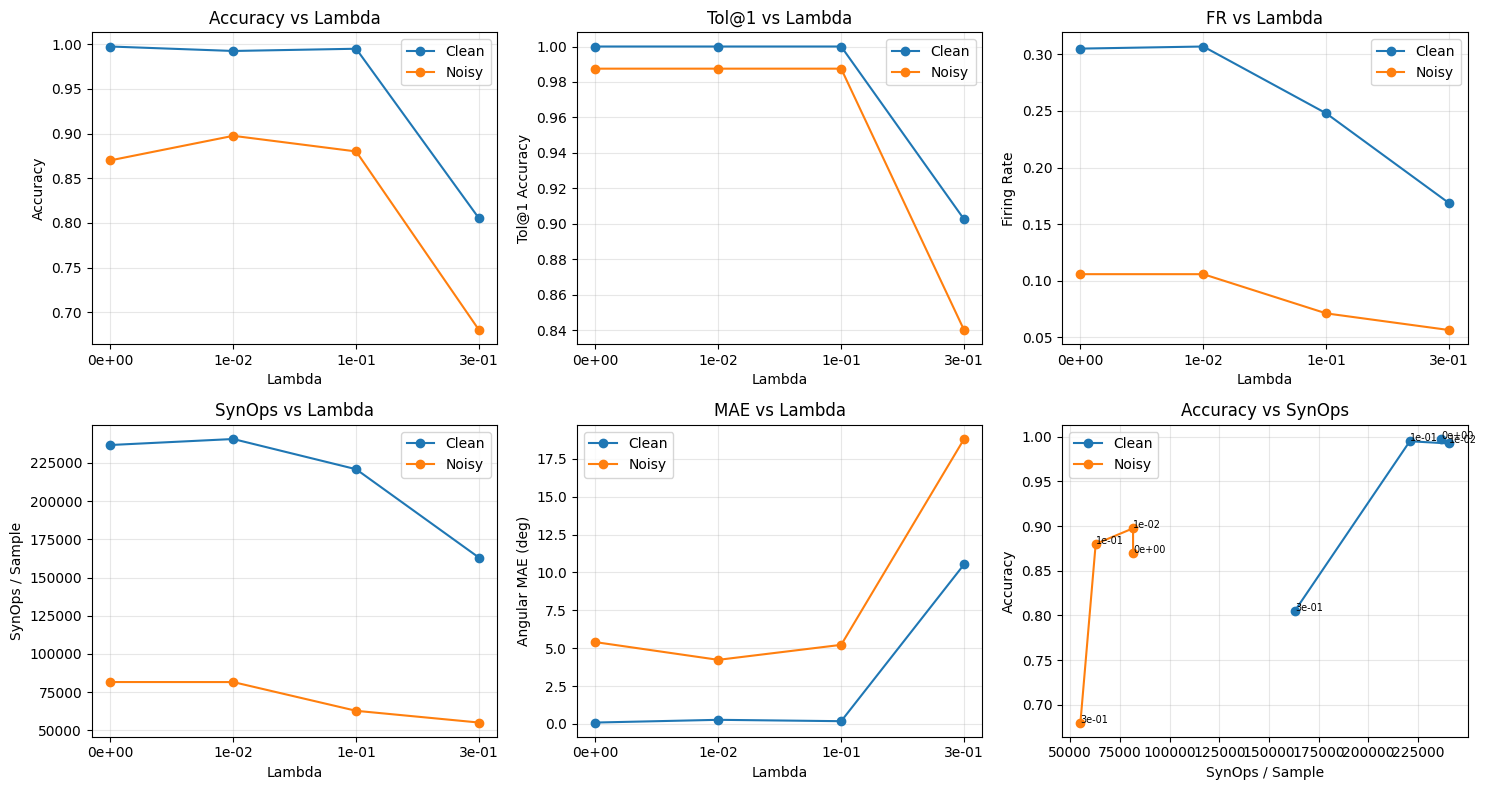

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(summary)
df_snn = df[df["model"] == "snn"].copy().sort_values("lambda")

x_labels = [f"{x:.0e}" for x in df_snn["lambda"]]
x_pos = range(len(x_labels))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# 1) Accuracy vs Lambda
ax = axes[0, 0]
ax.plot(x_pos, df_snn["clean_acc"], marker="o", label="Clean")
ax.plot(x_pos, df_snn["noisy_acc"], marker="o", label="Noisy")
ax.set_xticks(list(x_pos))
ax.set_xticklabels(x_labels)
ax.set_xlabel("Lambda")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs Lambda")
ax.grid(True, alpha=0.3)
ax.legend()

# 2) Tolerance@1 vs Lambda
ax = axes[0, 1]
ax.plot(x_pos, df_snn["clean_tol1_acc"], marker="o", label="Clean")
ax.plot(x_pos, df_snn["noisy_tol1_acc"], marker="o", label="Noisy")
ax.set_xticks(list(x_pos))
ax.set_xticklabels(x_labels)
ax.set_xlabel("Lambda")
ax.set_ylabel("Tol@1 Accuracy")
ax.set_title("Tol@1 vs Lambda")
ax.grid(True, alpha=0.3)
ax.legend()

# 3) FR vs Lambda
ax = axes[0, 2]
ax.plot(x_pos, df_snn["clean_fr"], marker="o", label="Clean")
ax.plot(x_pos, df_snn["noisy_fr"], marker="o", label="Noisy")
ax.set_xticks(list(x_pos))
ax.set_xticklabels(x_labels)
ax.set_xlabel("Lambda")
ax.set_ylabel("Firing Rate")
ax.set_title("FR vs Lambda")
ax.grid(True, alpha=0.3)
ax.legend()

# 4) SynOps vs Lambda
ax = axes[1, 0]
ax.plot(x_pos, df_snn["clean_synops"], marker="o", label="Clean")
ax.plot(x_pos, df_snn["noisy_synops"], marker="o", label="Noisy")
ax.set_xticks(list(x_pos))
ax.set_xticklabels(x_labels)
ax.set_xlabel("Lambda")
ax.set_ylabel("SynOps / Sample")
ax.set_title("SynOps vs Lambda")
ax.grid(True, alpha=0.3)
ax.legend()

# 5) MAE vs Lambda
ax = axes[1, 1]
ax.plot(x_pos, df_snn["clean_mae_deg"], marker="o", label="Clean")
ax.plot(x_pos, df_snn["noisy_mae_deg"], marker="o", label="Noisy")
ax.set_xticks(list(x_pos))
ax.set_xticklabels(x_labels)
ax.set_xlabel("Lambda")
ax.set_ylabel("Angular MAE (deg)")
ax.set_title("MAE vs Lambda")
ax.grid(True, alpha=0.3)
ax.legend()

# 6) Accuracy vs SynOps
ax = axes[1, 2]
ax.plot(df_snn["clean_synops"], df_snn["clean_acc"], marker="o", label="Clean")
ax.plot(df_snn["noisy_synops"], df_snn["noisy_acc"], marker="o", label="Noisy")
for _, row in df_snn.iterrows():
    ax.annotate(f"{row['lambda']:.0e}", (row["clean_synops"], row["clean_acc"]), fontsize=7)
    ax.annotate(f"{row['lambda']:.0e}", (row["noisy_synops"], row["noisy_acc"]), fontsize=7)
ax.set_xlabel("SynOps / Sample")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs SynOps")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## Research Extension

The cells above are kept close to the original baseline notebook. The cells below add the research-oriented pieces: 
- actual `CRNN` baseline comparison,
- surrogate-gradient comparison,
- SNN weight quantization,
- SNR robustness sweep, and
- a Pareto-style hardware-efficiency analysis.


In [15]:
print("GPU note:")
print("- If nvidia-smi shows 0%, that does not automatically mean CUDA is unused.")
print("- This project does STFT/log-mel feature extraction inside the Dataset on CPU.")
print("- The SNN itself is quite small, so GPU work happens in short bursts and nvidia-smi often samples 0% between bursts.")
if torch.cuda.is_available():
    x = torch.randn(2048, 2048, device=cfg.device)
    y = x @ x
    torch.cuda.synchronize()
    print("cuda memory allocated (MB):", round(torch.cuda.memory_allocated() / 1024**2, 2))
    del x, y
    torch.cuda.empty_cache()


GPU note:
- If nvidia-smi shows 0%, that does not automatically mean CUDA is unused.
- This project does STFT/log-mel feature extraction inside the Dataset on CPU.
- The SNN itself is quite small, so GPU work happens in short bursts and nvidia-smi often samples 0% between bursts.
cuda memory allocated (MB): 48.25


In [16]:
from pathlib import Path
def rebuild_summary_from_runs(run_list):
    rows = []
    for r in run_list:
        a = r["test_clean"]
        b = r["test_noisy"]
        rows.append({
            "model": r["model"],
            "label": r.get("label", f"{r['model']}_{r['lambda']:.0e}" if "lambda" in r else r["model"]),
            "lambda": r.get("lambda", r.get("lambda_fr", 0.0)),
            "clean_acc": a["acc"],
            "clean_tol1_acc": a["tol1_acc"],
            "clean_mae_deg": a["mae_deg"],
            "clean_fr": a["fr"],
            "clean_spikes_per_sample": a["spikes_per_sample"],
            "clean_synops": a["synops"],
            "noisy_acc": b["acc"],
            "noisy_tol1_acc": b["tol1_acc"],
            "noisy_mae_deg": b["mae_deg"],
            "noisy_fr": b["fr"],
            "noisy_spikes_per_sample": b["spikes_per_sample"],
            "noisy_synops": b["synops"],
        })
    return pd.DataFrame(rows)


def estimate_ops_proxy(row, cfg, t_frames):
    d_in = 2 * 2 * cfg.n_mels
    h = cfg.hidden_dim
    if row["model"] == "snn":
        return float(t_frames * (d_in * h + h * h) + row["noisy_synops"])
    return float(t_frames * 2 * (3 * (d_in * h + h * h + h)) + (2 * h * h) + (h * cfg.doa_bins))


def model_weight_kb(model, bits_override=None):
    total_bits = 0
    for name, param in model.named_parameters():
        bits = 32 if bits_override is None else bits_override.get(name, 32)
        total_bits += param.numel() * bits
    return total_bits / 8.0 / 1024.0


def train_baseline_with_model(model_name="crnn", lambda_fr=0.0, label="baseline"):
    set_seed(cfg.seed)
    if model_name == "snn":
        model = ProposalSNN_DOA(cfg).to(cfg.device)
    elif model_name == "crnn":
        model = ProposalCRNN_DOA(cfg).to(cfg.device)
    else:
        raise ValueError(model_name)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    best_acc = -1.0
    best_synops = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    patience = 0
    history = []
    for ep in range(cfg.epochs):
        tr = run_epoch(model, train_loader, optimizer, lambda_fr, cfg.device, True, cfg, model_name=model_name)
        va = run_epoch(model, val_loader, None, lambda_fr, cfg.device, False, cfg, model_name=model_name)
        history.append({"epoch": ep, "train": tr, "val": va})
        print(f"[{label}] epoch={ep:02d} | train acc={tr['acc']:.3f} | val acc={va['acc']:.3f} tol1={va['tol1_acc']:.3f}")
        improved = (va["acc"] > best_acc + 0.005) or (abs(va["acc"] - best_acc) <= 0.005 and va["synops"] < best_synops)
        if improved:
            best_acc = va["acc"]
            best_synops = va["synops"]
            best_state = copy.deepcopy(model.state_dict())
            patience = 0
        else:
            patience += 1
        if ep >= 2 and patience >= 3:
            print(f"early stopping at epoch {ep:02d}")
            break
    model.load_state_dict(best_state)
    test_clean = run_epoch(model, test_clean_loader, None, lambda_fr, cfg.device, False, cfg, model_name=model_name)
    test_noisy = run_epoch(model, test_noisy_loader, None, lambda_fr, cfg.device, False, cfg, model_name=model_name)
    return {
        "model": model_name,
        "label": label,
        "lambda": lambda_fr,
        "lambda_fr": lambda_fr,
        "history": history,
        "test_clean": test_clean,
        "test_noisy": test_noisy,
        "model_ref": model,
    }


if not any(r["model"] == "crnn" for r in results):
    print("Running CRNN baseline for direct comparison...")
    crnn_out = train_baseline_with_model(model_name="crnn", lambda_fr=0.0, label="crnn_baseline")
    results.append(crnn_out)

for r in results:
    if "label" not in r:
        r["label"] = f"{r['model']}_lambda={r['lambda']:.0e}"

artifact_dir = Path("research_artifacts")
artifact_dir.mkdir(exist_ok=True)
main_df = rebuild_summary_from_runs(results)
main_df["noisy_ops_proxy"] = [estimate_ops_proxy(row, cfg, xb0.shape[0]) for _, row in main_df.iterrows()]
main_df["weight_kb"] = 0.0
for i, r in enumerate(results):
    if r["model"] == "snn":
        tmp_model = ProposalSNN_DOA(cfg).to(cfg.device)
    else:
        tmp_model = ProposalCRNN_DOA(cfg).to(cfg.device)
    if r["history"]:
        pass
    main_df.loc[i, "weight_kb"] = model_weight_kb(tmp_model)
    del tmp_model
main_df.to_csv(artifact_dir / "main_with_crnn.csv", index=False)
display(main_df.round(4))


Running CRNN baseline for direct comparison...
[crnn_baseline] epoch=00 | train acc=0.618 | val acc=0.700 tol1=0.915
[crnn_baseline] epoch=01 | train acc=0.873 | val acc=0.853 tol1=0.983
[crnn_baseline] epoch=02 | train acc=0.920 | val acc=0.890 tol1=0.993
[crnn_baseline] epoch=03 | train acc=0.937 | val acc=0.892 tol1=0.985
[crnn_baseline] epoch=04 | train acc=0.954 | val acc=0.938 tol1=1.000
[crnn_baseline] epoch=05 | train acc=0.952 | val acc=0.900 tol1=0.995
[crnn_baseline] epoch=06 | train acc=0.965 | val acc=0.885 tol1=0.988
[crnn_baseline] epoch=07 | train acc=0.958 | val acc=0.908 tol1=0.990
early stopping at epoch 07


,model,label,lambda,clean_acc,clean_tol1_acc,clean_mae_deg,clean_fr,clean_spikes_per_sample,clean_synops,noisy_acc,noisy_tol1_acc,noisy_mae_deg,noisy_fr,noisy_spikes_per_sample,noisy_synops,noisy_ops_proxy,weight_kb
0,snn,snn_lambda=0e+00,0.00,0.9975,1.0000,0.09,0.3051,4919.8894,236684.4279,0.8700,0.9875,5.40,0.1058,1706.7692,81625.7308,2.662106e+06,99.7891
1,snn,snn_lambda=1e-02,0.01,0.9925,1.0000,0.27,0.3069,4949.7284,240609.9038,0.8975,0.9875,4.23,0.1058,1706.6034,81605.7692,2.662086e+06,99.7891
2,snn,snn_lambda=1e-01,0.10,0.9950,1.0000,0.18,0.2479,3997.5865,220839.2596,0.8800,0.9875,5.22,0.0712,1148.2788,62805.5048,2.643286e+06,99.7891
3,snn,snn_lambda=3e-01,0.30,0.8050,0.9025,10.53,0.1685,2718.1466,162997.8269,0.6800,0.8400,18.81,0.0565,910.8413,55125.6298,2.635606e+06,99.7891
4,crnn,crnn_baseline,0.00,0.9950,1.0000,0.18,0.0000,0.0000,0.0000,0.9700,1.0000,1.08,0.0000,0.0000,0.0000,1.554010e+07,517.7891


In [17]:
class ResearchSurrogateSpike(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, surrogate_type, alpha):
        ctx.save_for_backward(x)
        ctx.surrogate_type = surrogate_type
        ctx.alpha = alpha
        return (x > 0).float()

    @staticmethod
    def backward(ctx, grad_output):
        (x,) = ctx.saved_tensors
        a = ctx.alpha
        if ctx.surrogate_type == "fast_sigmoid":
            grad = 1.0 / (1.0 + a * x.abs()).pow(2)
        elif ctx.surrogate_type == "triangular":
            grad = (1.0 - a * x.abs()).clamp(min=0.0)
        elif ctx.surrogate_type == "gaussian":
            grad = torch.exp(-0.5 * (a * x).pow(2))
        else:
            raise ValueError(ctx.surrogate_type)
        return grad_output * grad, None, None


def research_spike_fn(x, surrogate_type="fast_sigmoid", alpha=2.0):
    return ResearchSurrogateSpike.apply(x, surrogate_type, alpha)


def fake_quantize_ste(x, bits):
    if bits is None or bits >= 32:
        return x
    qmax = 2 ** (bits - 1) - 1
    scale = x.detach().abs().max().clamp(min=1e-8) / max(qmax, 1)
    q = torch.clamp(torch.round(x / scale), -qmax, qmax) * scale
    return x + (q - x).detach()


class ResearchQuantLinear(nn.Linear):
    def __init__(self, dim_in, dim_out, bias=True, weight_bits=32):
        super().__init__(dim_in, dim_out, bias=bias)
        self.weight_bits = weight_bits

    def forward(self, x):
        return F.linear(x, fake_quantize_ste(self.weight, self.weight_bits), self.bias)


class ResearchLIFLayer(nn.Module):
    def __init__(self, dim_in, dim_out, beta=0.95, v_th=1.2, surrogate_type="fast_sigmoid", alpha=2.0, weight_bits=32):
        super().__init__()
        self.fc = ResearchQuantLinear(dim_in, dim_out, weight_bits=weight_bits)
        self.beta = beta
        self.v_th = v_th
        self.surrogate_type = surrogate_type
        self.alpha = alpha

    def forward(self, x_seq):
        B, T, _ = x_seq.shape
        mem = torch.zeros(B, self.fc.out_features, device=x_seq.device)
        spikes = []
        spike_count = torch.zeros((), device=x_seq.device)
        for t in range(T):
            mem = self.beta * mem + self.fc(x_seq[:, t])
            spk = research_spike_fn(mem - self.v_th, self.surrogate_type, self.alpha)
            mem = mem * (1.0 - spk)
            spikes.append(spk)
            spike_count = spike_count + spk.sum()
        spk_seq = torch.stack(spikes, dim=1)
        return spk_seq, spk_seq.mean(), spike_count


class ResearchSNN_DOA(nn.Module):
    def __init__(self, cfg, surrogate_type="fast_sigmoid", weight_bits=32):
        super().__init__()
        self.cfg = cfg
        self.surrogate_type = surrogate_type
        self.weight_bits = weight_bits
        d_in = 2 * 2 * cfg.n_mels
        h = cfg.hidden_dim
        self.d_in = d_in
        self.h = h
        self.in_proj = ResearchQuantLinear(d_in, h, weight_bits=weight_bits)
        self.norm = nn.LayerNorm(h)
        self.lif1 = ResearchLIFLayer(h, h, surrogate_type=surrogate_type, weight_bits=weight_bits)
        self.lif2 = ResearchLIFLayer(h, h, surrogate_type=surrogate_type, weight_bits=weight_bits)
        self.drop = nn.Dropout(cfg.dropout)
        self.readout = ResearchQuantLinear(h, cfg.doa_bins, weight_bits=weight_bits)

    def forward(self, x):
        B, T, C, M, Fq = x.shape
        x = torch.tanh(self.norm(self.in_proj(x.reshape(B, T, C * M * Fq))))
        s1, fr1, spk1 = self.lif1(x)
        s2, fr2, spk2 = self.lif2(s1)
        logits = self.readout(self.drop(s2.mean(dim=1)))
        synops = (spk1 * self.h + spk2 * self.cfg.doa_bins) / B
        dense_ops = torch.tensor(float(T * (self.d_in * self.h + self.h * self.h)), device=x.device)
        return logits, {
            "fr": 0.5 * (fr1 + fr2),
            "spikes_per_sample": (spk1 + spk2) / B,
            "synops_per_sample": synops,
            "ops_proxy_per_sample": dense_ops + synops,
        }


In [18]:
def run_research_epoch(model, loader, optimizer, lambda_fr, cfg, train=True):
    model.train(train)
    total_loss, total_samples = 0.0, 0
    pred_all, true_all = [], []
    fr_list, sps_list, synops_list, ops_list = [], [], [], []
    for xb, yb in loader:
        xb = xb.to(cfg.device, non_blocking=True)
        yb = yb.to(cfg.device, non_blocking=True)
        if train:
            optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(train):
            logits, stats = model(xb)
            cls_loss = F.cross_entropy(logits, yb)
            fr_loss = F.relu(stats["spikes_per_sample"] - 600.0) / 600.0
            loss = cls_loss + lambda_fr * fr_loss
            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer.step()
        pred = logits.argmax(dim=1)
        total_loss += float(loss.detach().cpu()) * xb.size(0)
        total_samples += xb.size(0)
        pred_all.extend(pred.detach().cpu().tolist())
        true_all.extend(yb.detach().cpu().tolist())
        fr_list.append(float(stats["fr"].detach().cpu()))
        sps_list.append(float(stats["spikes_per_sample"].detach().cpu()))
        synops_list.append(float(stats["synops_per_sample"].detach().cpu()))
        ops_list.append(float(stats["ops_proxy_per_sample"].detach().cpu()))
    pred_t, true_t = torch.tensor(pred_all), torch.tensor(true_all)
    return {
        "loss": total_loss / max(total_samples, 1),
        "acc": float((pred_t == true_t).float().mean().item()) if len(pred_t) > 0 else 0.0,
        "tol1_acc": tolerant_acc(pred_t, true_t, cfg.doa_bins, tol_bins=cfg.pred_tol_bins),
        "mae_deg": batch_angular_mae_deg_single(pred_t, true_t, cfg.doa_bins),
        "fr": float(np.mean(fr_list)) if fr_list else 0.0,
        "spikes_per_sample": float(np.mean(sps_list)) if sps_list else 0.0,
        "synops": float(np.mean(synops_list)) if synops_list else 0.0,
        "ops_proxy": float(np.mean(ops_list)) if ops_list else 0.0,
    }


def train_research_snn(base_cfg, lambda_fr, surrogate_type, weight_bits, label):
    local_cfg = copy.deepcopy(base_cfg)
    model = ResearchSNN_DOA(local_cfg, surrogate_type=surrogate_type, weight_bits=weight_bits).to(local_cfg.device)
    optimizer = torch.optim.Adam(model.parameters(), lr=local_cfg.lr)
    best_state = copy.deepcopy(model.state_dict())
    best_acc, best_ops, patience = -1.0, float("inf"), 0
    history = []
    for ep in range(local_cfg.epochs):
        tr = run_research_epoch(model, train_loader, optimizer, lambda_fr, local_cfg, train=True)
        va = run_research_epoch(model, val_loader, None, lambda_fr, local_cfg, train=False)
        history.append({"epoch": ep, "train": tr, "val": va})
        print(f"[{label}] epoch={ep:02d} | train acc={tr['acc']:.3f} | val acc={va['acc']:.3f} tol1={va['tol1_acc']:.3f} mae={va['mae_deg']:.2f} synops={va['synops']:.0f} ops={va['ops_proxy']:.0f}")
        improved = (va["acc"] > best_acc + 1e-3) or (abs(va["acc"] - best_acc) <= 1e-3 and va["ops_proxy"] < best_ops)
        if improved:
            best_acc, best_ops, best_state, patience = va["acc"], va["ops_proxy"], copy.deepcopy(model.state_dict()), 0
        else:
            patience += 1
        if ep >= 2 and patience >= 3:
            print(f"early stopping at epoch {ep:02d}")
            break
    model.load_state_dict(best_state)
    test_clean = run_research_epoch(model, test_clean_loader, None, lambda_fr, local_cfg, train=False)
    test_noisy = run_research_epoch(model, test_noisy_loader, None, lambda_fr, local_cfg, train=False)
    weight_bits_map = {}
    if weight_bits < 32:
        for name, param in model.named_parameters():
            if any(tag in name for tag in ("in_proj.weight", "lif1.fc.weight", "lif2.fc.weight", "readout.weight")):
                weight_bits_map[name] = weight_bits
    return {
        "study": "research",
        "model": "snn",
        "label": label,
        "lambda": lambda_fr,
        "lambda_fr": lambda_fr,
        "surrogate": surrogate_type,
        "surrogate_type": surrogate_type,
        "weight_bits": weight_bits,
        "weight_kb": model_weight_kb(model, weight_bits_map),
        "test_clean": test_clean,
        "test_noisy": test_noisy,
        "history": history,
        "model_ref": model,
    }


def build_fixed_snr_loader(snr_db):
    eval_cfg = copy.deepcopy(cfg)
    eval_cfg.eval_noise_prob = 1.0
    eval_cfg.noise_snr_db_min = float(snr_db)
    eval_cfg.noise_snr_db_max = float(snr_db)
    eval_ds = CachedSyntheticBinauralDOADataset(test_clips, cfg.test_size, eval_cfg, training=False, cache_all=True)
    return DataLoader(eval_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())


def pareto_front(df, x_col, y_col):
    order = df.sort_values(x_col)
    best_y = -1.0
    keep = []
    for idx, row in order.iterrows():
        if row[y_col] > best_y:
            best_y = row[y_col]
            keep.append(idx)
    return df.loc[keep].sort_values(x_col)


In [19]:
snn_main_df = main_df[main_df["model"] == "snn"].copy().sort_values(["noisy_acc", "noisy_synops"], ascending=[False, True])
best_lambda = float(snn_main_df.iloc[0]["lambda"])
print("Best lambda from original SNN sweep:", best_lambda)

surrogate_runs = []
for surrogate_name in ("fast_sigmoid", "triangular", "gaussian"):
    surrogate_runs.append(train_research_snn(cfg, best_lambda, surrogate_name, 32, f"surrogate_{surrogate_name}"))

surrogate_df = rebuild_summary_from_runs(surrogate_runs)
surrogate_df["surrogate"] = [r["surrogate_type"] for r in surrogate_runs]
surrogate_df["weight_bits"] = [r["weight_bits"] for r in surrogate_runs]
surrogate_df["weight_kb"] = [r["weight_kb"] for r in surrogate_runs]
surrogate_df["noisy_ops_proxy"] = [r["test_noisy"]["ops_proxy"] for r in surrogate_runs]
surrogate_df.to_csv(artifact_dir / "surrogate_study.csv", index=False)
display(surrogate_df.round(4))

best_surrogate_run = sorted(surrogate_runs, key=lambda r: (-r["test_noisy"]["acc"], r["test_noisy"]["ops_proxy"]))[0]
best_surrogate = best_surrogate_run["surrogate_type"]
print("Best surrogate:", best_surrogate)

quant_runs = []
for bits in (32, 8, 4):
    quant_runs.append(train_research_snn(cfg, best_lambda, best_surrogate, bits, f"quant_{bits}bit"))

quant_df = rebuild_summary_from_runs(quant_runs)
quant_df["surrogate"] = [r["surrogate_type"] for r in quant_runs]
quant_df["weight_bits"] = [r["weight_bits"] for r in quant_runs]
quant_df["weight_kb"] = [r["weight_kb"] for r in quant_runs]
quant_df["noisy_ops_proxy"] = [r["test_noisy"]["ops_proxy"] for r in quant_runs]
quant_df.to_csv(artifact_dir / "quant_study.csv", index=False)
display(quant_df.round(4))

best_fp32_snn = [r for r in quant_runs if r["weight_bits"] == 32][0]
crnn_run = [r for r in results if r["model"] == "crnn"][0]

snr_rows = []
for snr_db in (-10, -5, 0, 5, 10, 15, 20):
    loader = build_fixed_snr_loader(snr_db)
    snn_metrics = run_research_epoch(best_fp32_snn["model_ref"], loader, None, best_fp32_snn["lambda_fr"], cfg, train=False)

    crnn_metrics = run_epoch(crnn_run["model_ref"], loader, None, 0.0, cfg.device, False, cfg, model_name="crnn")
    snr_rows.append({"run_label": "best_snn_fp32", "snr_db": snr_db, **snn_metrics})
    snr_rows.append({"run_label": "crnn_baseline", "snr_db": snr_db, **crnn_metrics})

snr_df = pd.DataFrame(snr_rows)
snr_df.to_csv(artifact_dir / "snr_sweep.csv", index=False)
display(snr_df.round(4))


Best lambda from original SNN sweep: 0.01
[surrogate_fast_sigmoid] epoch=00 | train acc=0.372 | val acc=0.562 tol1=0.830 mae=29.34 synops=50116 ops=2630596
[surrogate_fast_sigmoid] epoch=01 | train acc=0.831 | val acc=0.738 tol1=0.943 mae=12.06 synops=85211 ops=2665691
[surrogate_fast_sigmoid] epoch=02 | train acc=0.890 | val acc=0.805 tol1=0.983 mae=7.83 synops=96957 ops=2677437
[surrogate_fast_sigmoid] epoch=03 | train acc=0.892 | val acc=0.822 tol1=0.963 mae=8.55 synops=101389 ops=2681869
[surrogate_fast_sigmoid] epoch=04 | train acc=0.924 | val acc=0.873 tol1=0.983 mae=5.40 synops=106510 ops=2686990
[surrogate_fast_sigmoid] epoch=05 | train acc=0.933 | val acc=0.870 tol1=0.980 mae=5.58 synops=106866 ops=2687346
[surrogate_fast_sigmoid] epoch=06 | train acc=0.927 | val acc=0.875 tol1=0.990 mae=5.04 synops=108136 ops=2688616
[surrogate_fast_sigmoid] epoch=07 | train acc=0.929 | val acc=0.895 tol1=0.978 mae=4.77 synops=109924 ops=2690404
[surrogate_fast_sigmoid] epoch=08 | train acc=0

,model,label,lambda,clean_acc,clean_tol1_acc,clean_mae_deg,clean_fr,clean_spikes_per_sample,clean_synops,noisy_acc,noisy_tol1_acc,noisy_mae_deg,noisy_fr,noisy_spikes_per_sample,noisy_synops,surrogate,weight_bits,weight_kb,noisy_ops_proxy
0,snn,surrogate_fast_sigmoid,0.01,0.9950,1.000,0.18,0.3753,6053.3822,227796.7452,0.9525,0.9950,2.07,0.1912,3082.9615,110682.7644,fast_sigmoid,32,99.7891,2.691163e+06
1,snn,surrogate_triangular,0.01,0.9925,1.000,0.27,0.3715,5990.9832,211453.1731,0.9200,0.9900,3.33,0.2253,3633.3365,120401.8894,triangular,32,99.7891,2.700882e+06
2,snn,surrogate_gaussian,0.01,0.9325,0.985,3.06,0.1204,1942.3486,84986.2356,0.4425,0.6725,37.53,0.0613,988.9111,43484.8990,gaussian,32,99.7891,2.623965e+06


Best surrogate: fast_sigmoid
[quant_32bit] epoch=00 | train acc=0.484 | val acc=0.680 tol1=0.938 mae=14.22 synops=57580 ops=2638060
[quant_32bit] epoch=01 | train acc=0.804 | val acc=0.772 tol1=0.965 mae=9.81 synops=89196 ops=2669676
[quant_32bit] epoch=02 | train acc=0.906 | val acc=0.848 tol1=0.993 mae=5.76 synops=98459 ops=2678939
[quant_32bit] epoch=03 | train acc=0.900 | val acc=0.825 tol1=0.978 mae=7.29 synops=104521 ops=2685001
[quant_32bit] epoch=04 | train acc=0.930 | val acc=0.858 tol1=0.993 mae=5.40 synops=106390 ops=2686870
[quant_32bit] epoch=05 | train acc=0.929 | val acc=0.877 tol1=0.993 mae=4.68 synops=108360 ops=2688840
[quant_32bit] epoch=06 | train acc=0.928 | val acc=0.837 tol1=0.965 mae=7.29 synops=110403 ops=2690883
[quant_32bit] epoch=07 | train acc=0.940 | val acc=0.890 tol1=0.993 mae=4.32 synops=111882 ops=2692362
[quant_32bit] epoch=08 | train acc=0.949 | val acc=0.905 tol1=0.988 mae=4.05 synops=112609 ops=2693089
[quant_32bit] epoch=09 | train acc=0.935 | val

,model,label,lambda,clean_acc,clean_tol1_acc,clean_mae_deg,clean_fr,clean_spikes_per_sample,clean_synops,noisy_acc,noisy_tol1_acc,noisy_mae_deg,noisy_fr,noisy_spikes_per_sample,noisy_synops,surrogate,weight_bits,weight_kb,noisy_ops_proxy
0,snn,quant_32bit,0.01,0.9975,1.0,0.09,0.3945,6362.0601,236365.8221,0.9275,0.9850,3.24,0.1997,3220.5385,112534.5385,fast_sigmoid,32,99.7891,2.693015e+06
1,snn,quant_8bit,0.01,0.9925,1.0,0.27,0.3971,6404.4135,240500.6875,0.9175,0.9825,4.05,0.2075,3347.2644,118713.0721,fast_sigmoid,8,25.9141,2.699193e+06
2,snn,quant_4bit,0.01,0.9925,1.0,0.27,0.4162,6712.7043,247354.5096,0.9375,0.9950,2.43,0.2133,3440.2981,121795.1010,fast_sigmoid,4,13.6016,2.702275e+06


,run_label,snr_db,loss,acc,tol1_acc,mae_deg,fr,spikes_per_sample,synops,ops_proxy,cls_loss_mean,fr_loss_mean,reg_loss_mean
0,best_snn_fp32,-10,2.0243,0.2575,0.5800,55.08,0.1792,2889.8534,105021.9183,2.685502e+06,NaN,NaN,NaN
1,crnn_baseline,-10,2.1528,0.2875,0.6325,48.87,0.0000,0.0000,0.0000,NaN,2.1511,0.0,0.0
2,best_snn_fp32,-5,1.5905,0.3900,0.7500,36.27,0.1793,2892.3582,103499.7885,2.683980e+06,NaN,NaN,NaN
3,crnn_baseline,-5,1.6320,0.4400,0.7575,33.30,0.0000,0.0000,0.0000,NaN,1.6446,0.0,0.0
4,best_snn_fp32,0,1.2061,0.6025,0.9025,19.35,0.1799,2901.5986,102863.7115,2.683344e+06,NaN,NaN,NaN
5,crnn_baseline,0,0.6990,0.7750,0.9600,9.81,0.0000,0.0000,0.0000,NaN,0.6956,0.0,0.0
6,best_snn_fp32,5,0.8428,0.8000,0.9675,8.82,0.1859,2998.6202,105212.7452,2.685693e+06,NaN,NaN,NaN
7,crnn_baseline,5,0.3268,0.8725,0.9825,5.40,0.0000,0.0000,0.0000,NaN,0.3295,0.0,0.0
8,best_snn_fp32,10,0.6087,0.9100,0.9950,3.42,0.1918,3093.4447,107955.0625,2.688435e+06,NaN,NaN,NaN
9,crnn_baseline,10,0.1863,0.9375,0.9975,2.43,0.0000,0.0000,0.0000,NaN,0.1983,0.0,0.0


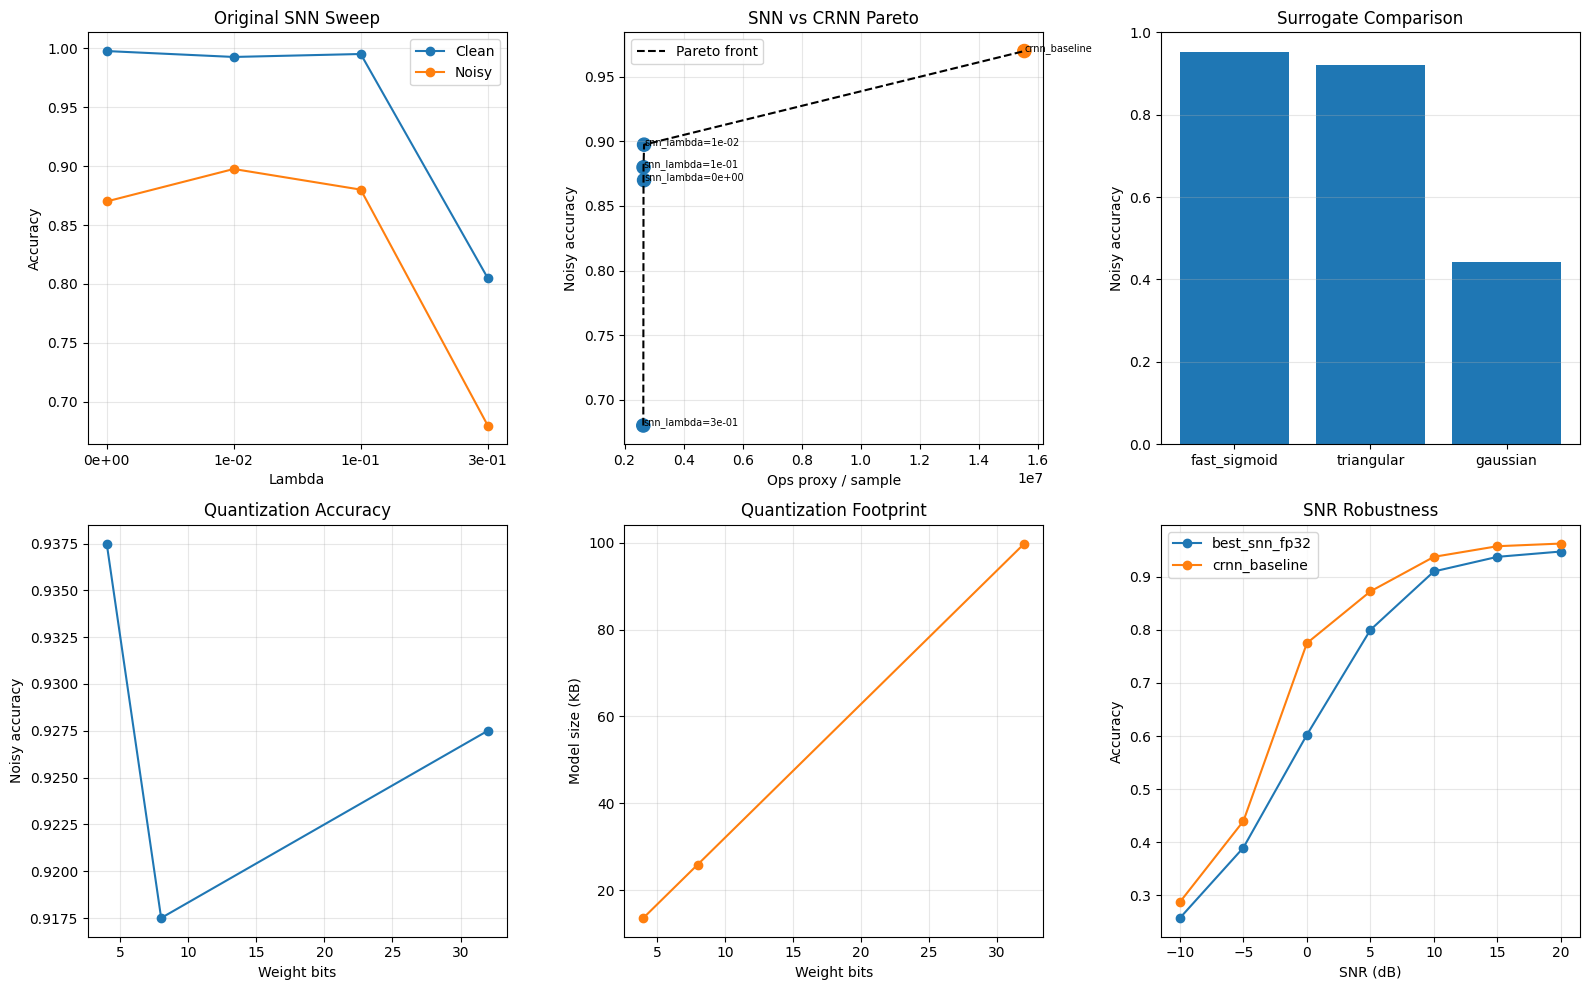

Report-ready observations
--------------------------------------------------------------------------------
Best original lambda: 0.01
Best surrogate: fast_sigmoid
CRNN noisy acc: 0.970
Best FP32 SNN noisy acc: 0.928
Best 4-bit SNN noisy acc: 0.938


In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

df_snn = main_df[main_df["model"] == "snn"].copy().sort_values("lambda")
x_labels = [f"{x:.0e}" for x in df_snn["lambda"]]
x_pos = np.arange(len(x_labels))

ax = axes[0, 0]
ax.plot(x_pos, df_snn["clean_acc"], marker="o", label="Clean")
ax.plot(x_pos, df_snn["noisy_acc"], marker="o", label="Noisy")
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_xlabel("Lambda")
ax.set_ylabel("Accuracy")
ax.set_title("Original SNN Sweep")
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[0, 1]
ax.scatter(main_df["noisy_ops_proxy"], main_df["noisy_acc"], c=main_df["model"].map({"snn": "tab:blue", "crnn": "tab:orange"}), s=90)
for _, row in main_df.iterrows():
    ax.annotate(row["label"], (row["noisy_ops_proxy"], row["noisy_acc"]), fontsize=7)
front = pareto_front(main_df, "noisy_ops_proxy", "noisy_acc")
ax.plot(front["noisy_ops_proxy"], front["noisy_acc"], linestyle="--", color="black", label="Pareto front")
ax.set_xlabel("Ops proxy / sample")
ax.set_ylabel("Noisy accuracy")
ax.set_title("SNN vs CRNN Pareto")
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[0, 2]
ax.bar(surrogate_df["surrogate"], surrogate_df["noisy_acc"], color="tab:blue")
ax.set_ylabel("Noisy accuracy")
ax.set_title("Surrogate Comparison")
ax.grid(True, axis="y", alpha=0.3)

ax = axes[1, 0]
ax.plot(quant_df["weight_bits"], quant_df["noisy_acc"], marker="o", label="Noisy accuracy")
ax.set_xlabel("Weight bits")
ax.set_ylabel("Noisy accuracy")
ax.set_title("Quantization Accuracy")
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(quant_df["weight_bits"], quant_df["weight_kb"], marker="o", color="tab:orange")
ax.set_xlabel("Weight bits")
ax.set_ylabel("Model size (KB)")
ax.set_title("Quantization Footprint")
ax.grid(True, alpha=0.3)

ax = axes[1, 2]
for label, subdf in snr_df.groupby("run_label"):
    ax.plot(subdf["snr_db"], subdf["acc"], marker="o", label=label)
ax.set_xlabel("SNR (dB)")
ax.set_ylabel("Accuracy")
ax.set_title("SNR Robustness")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()
fig.savefig(artifact_dir / "research_summary_plots.png", dpi=160, bbox_inches="tight")

print("Report-ready observations")
print("-" * 80)
print(f"Best original lambda: {best_lambda:g}")
print(f"Best surrogate: {best_surrogate}")
print(f"CRNN noisy acc: {main_df[main_df['model'] == 'crnn'].iloc[0]['noisy_acc']:.3f}")
print(f"Best FP32 SNN noisy acc: {best_fp32_snn['test_noisy']['acc']:.3f}")
print(f"Best 4-bit SNN noisy acc: {quant_df[quant_df['weight_bits'] == 4].iloc[0]['noisy_acc']:.3f}")
